
# LLM 기반 리뷰 분석

`02_review_bertopic_modeling.ipynb`에서 생성된 집계 JSON을 입력으로 받아 LLM을 활용합니다.

**LLM의 역할은 두 단계로 제한합니다:**
1. BERTopic 토픽 키워드 → 카테고리 레이블 자동 부여 (bug / balance / price / performance / content / positive / other)
2. pandas로 계산한 카테고리별 비율표 → 개발사 액션 제안 서술

**LLM이 하지 않는 것:**
- 리뷰 원문 직접 읽기
- 카테고리 건수 추정
- 비율 직접 계산

**분석 흐름**
```
data/processed/review_analysis_summary_{appid}.json  ← 02_ 출력
    ↓
[LLM 1차] 토픽 키워드 레이블링
    ↓
카테고리별 비율 집계 (pandas)
    ↓
[LLM 2차] 집계표 기반 액션 제안
```


In [1]:
import os
import json
import platform
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from google import genai
from google.genai import types
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
MODEL = 'gemini-3-flash-preview'
print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# 분석 대상 게임 설정
TARGET_APPID = 1054510

summary_path = f'../../../../data/processed/review_analysis_summary_{TARGET_APPID}.json'
with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)

print(f"[appid={TARGET_APPID}] 집계 데이터 로드 완료")
print(f"  전체 리뷰: {summary['total_reviews']:,}건")
print(f"  부정: {summary['negative']['count']}건 / 긍정: {summary['positive']['count']}건")
print(f"  부정 토픽 수: {len(summary['negative']['topics'])}개")
print(f"  긍정 토픽 수: {len(summary['positive']['topics'])}개")

[appid=1054510] 집계 데이터 로드 완료
  전체 리뷰: 1,500건
  부정: 181건 / 긍정: 1319건
  부정 토픽 수: 5개
  긍정 토픽 수: 11개



## LLM 1차 호출: 토픽 카테고리 레이블링

부정/긍정 토픽 키워드와 건수를 전달하여 각 토픽의 카테고리만 분류합니다.

**출력 구조:**
- `neg_labels`: 부정 토픽 → 카테고리 매핑
- `pos_labels`: 긍정 토픽 → 카테고리 매핑


In [5]:

VALID_CATEGORIES = ['bug', 'balance', 'price', 'performance', 'content', 'positive', 'other']


def build_labeling_prompt(summary: dict) -> str:
    def fmt_topics(topics):
        if not topics:
            return '  - 토픽 없음'
        return '\n'.join(
            f'  - topic_id {t["topic_id"]} ({t["count"]}건): {", ".join(t["keywords"])}'
            for t in topics
        )

    return f"""아래는 Steam 인디게임(appid={summary['appid']}) 리뷰의 BERTopic 결과입니다.
각 토픽을 허용 카테고리 중 하나로만 분류하세요.

허용 카테고리:
- bug: 버그, 크래시, 진행 불가, 깨진 기능
- balance: 난이도, 밸런스, 반복 노동, 보상 구조
- price: 가격, 할인, 가성비, 환불
- performance: 최적화, 프레임, 로딩, 하드웨어 성능 문제
- content: 콘텐츠 분량, 스토리, 아트, 조작, 시스템, UI/UX
- positive: 명확한 호평, 재미, 만족, 추천, 강점
- other: 위 기준으로 판단하기 어려움

[부정 리뷰 BERTopic 토픽]
{fmt_topics(summary['negative']['topics'])}

[긍정 리뷰 BERTopic 토픽]
{fmt_topics(summary['positive']['topics'])}

반드시 아래 JSON 형식으로만 응답하세요 (다른 텍스트 없이):
{{
  "neg_labels": [{{"topic_id": <int>, "category": "<category>"}}],
  "pos_labels": [{{"topic_id": <int>, "category": "<category>"}}]
}}"""


def validate_labels(labels: dict[int, str], topics: list[dict], name: str) -> dict[int, str]:
    topic_ids = {int(t['topic_id']) for t in topics}
    cleaned = {}
    for topic_id in topic_ids:
        category = labels.get(topic_id, 'other')
        if category not in VALID_CATEGORIES:
            print(f"{name} topic {topic_id}: 허용되지 않은 카테고리 '{category}' → other")
            category = 'other'
        cleaned[topic_id] = category
    return cleaned


def label_topics(summary: dict) -> dict:
    prompt = build_labeling_prompt(summary)
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type='application/json',
            temperature=0.2,
        ),
    )
    return json.loads(response.text)


print('LLM 토픽 레이블링 중 (1차 호출)...')
label_result = label_topics(summary)
print('완료!')

neg_labels_raw = {int(item['topic_id']): item['category'] for item in label_result['neg_labels']}
pos_labels_raw = {int(item['topic_id']): item['category'] for item in label_result['pos_labels']}
neg_labels = validate_labels(neg_labels_raw, summary['negative']['topics'], '부정')
pos_labels = validate_labels(pos_labels_raw, summary['positive']['topics'], '긍정')

print('\n부정 토픽 레이블:')
for tid, label in sorted(neg_labels.items()):
    print(f'  topic {tid} → {label}')
print('\n긍정 토픽 레이블:')
for tid, label in sorted(pos_labels.items()):
    print(f'  topic {tid} → {label}')


LLM 토픽 레이블링 중 (1차 호출)...
완료!

부정 토픽 레이블:
  topic 0 → content
  topic 1 → content
  topic 2 → content
  topic 3 → balance
  topic 4 → other

긍정 토픽 레이블:
  topic 0 → positive
  topic 1 → positive
  topic 2 → positive
  topic 3 → positive
  topic 4 → positive
  topic 5 → content
  topic 6 → positive
  topic 7 → balance
  topic 8 → price
  topic 9 → price
  topic 10 → content


## 카테고리별 비율 집계 및 시각화

LLM이 부여한 레이블로 토픽 건수를 카테고리별로 집계합니다.

In [6]:

def aggregate_by_category(topics: list[dict], labels: dict[int, str], total_count: int) -> pd.DataFrame:
    rows = [
        {'category': labels.get(int(t['topic_id']), 'other'), 'count': int(t['count'])}
        for t in topics
    ]
    assigned_count = sum(row['count'] for row in rows)
    unassigned_count = max(0, total_count - assigned_count)
    if unassigned_count:
        rows.append({'category': 'unassigned/noise', 'count': unassigned_count})

    df = pd.DataFrame(rows).groupby('category', as_index=False)['count'].sum()
    df['ratio(%)'] = (df['count'] / total_count * 100).round(1)
    return df.sort_values('count', ascending=False).reset_index(drop=True)


neg_cat_df = aggregate_by_category(summary['negative']['topics'], neg_labels, summary['negative']['count'])
pos_cat_df = aggregate_by_category(summary['positive']['topics'], pos_labels, summary['positive']['count'])

print('=== 부정 리뷰 카테고리 집계 ===')
display(neg_cat_df)
print('\n=== 긍정 리뷰 카테고리 집계 ===')
display(pos_cat_df)


=== 부정 리뷰 카테고리 집계 ===


,category,count,ratio(%)
0,content,125,69.1
1,unassigned/noise,25,13.8
2,balance,23,12.7
3,other,8,4.4



=== 긍정 리뷰 카테고리 집계 ===


,category,count,ratio(%)
0,positive,924,70.1
1,unassigned/noise,184,13.9
2,content,86,6.5
3,price,76,5.8
4,balance,49,3.7


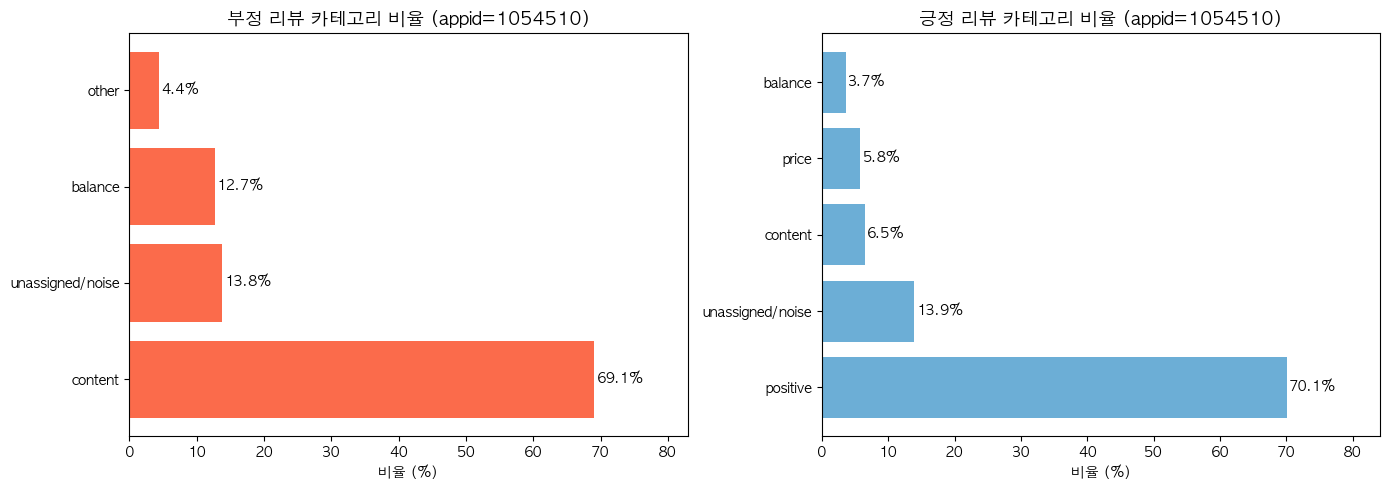

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in [
    (axes[0], neg_cat_df, '부정 리뷰 카테고리 비율', 'Reds_r'),
    (axes[1], pos_cat_df, '긍정 리뷰 카테고리 비율', 'Blues_r'),
]:
    bars = ax.barh(df['category'], df['ratio(%)'], color=plt.cm.get_cmap(color)(0.5))
    ax.set_xlabel('비율 (%)')
    ax.set_title(f'{title} (appid={TARGET_APPID})', fontsize=13)
    for bar, val in zip(bars, df['ratio(%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=10)
    ax.set_xlim(0, df['ratio(%)'].max() * 1.2)

plt.tight_layout()
plt.show()


## 개발자용 개선 제안 생성

앞에서 계산한 리뷰 불만/호평 비율을 바탕으로, 데이터 분석 지식이 없는 개발자도 바로 이해할 수 있는 개선 제안을 생성합니다. 사용자에게 보이는 문장에는 분석 모델명이나 통계 처리 용어를 사용하지 않습니다.


In [14]:
CATEGORY_LABELS_KR = {
    'bug': '버그/기능 오류',
    'balance': '난이도/밸런스/반복 피로감',
    'price': '가격/가성비',
    'performance': '성능/로딩/최적화',
    'content': '콘텐츠/조작/UI/게임 시스템',
    'positive': '명확한 호평/강점',
    'other': '기타 의견',
    'unassigned/noise': '분류가 애매한 의견',
}


def category_table_text(df: pd.DataFrame) -> str:
    return '\n'.join(
        f'  - {CATEGORY_LABELS_KR.get(row["category"], row["category"])}: '
        f'{int(row["count"])}건 ({row["ratio(%)"]:.1f}%)'
        for _, row in df.iterrows()
    )


def category_keywords_text(topics: list[dict], labels: dict[int, str]) -> str:
    from collections import defaultdict
    grouped = defaultdict(list)
    for t in topics:
        tid = int(t['topic_id'])
        category = labels.get(tid, 'other')
        grouped[category].extend(t['keywords'][:5])

    lines = []
    for category, keywords in grouped.items():
        label_kr = CATEGORY_LABELS_KR.get(category, category)
        unique_keywords = list(dict.fromkeys(keywords))
        lines.append(f'  - {label_kr}: {", ".join(unique_keywords)}')
    return '\n'.join(lines)


def review_interpretation_note(summary: dict) -> str:
    notes = []
    for sentiment_key, sentiment_name in [('negative', '부정 리뷰'), ('positive', '긍정 리뷰')]:
        diagnostics = summary[sentiment_key].get('diagnostics', {})
        if diagnostics.get('largest_topic_ratio', 0) >= 0.5:
            notes.append(f'- {sentiment_name}: 여러 의견이 하나의 큰 흐름으로 섞여 있어, 세부 원인은 대표 리뷰와 함께 확인하는 것이 좋습니다.')
        if diagnostics.get('noise_ratio', 0) >= 0.4:
            notes.append(f'- {sentiment_name}: 분류가 애매한 리뷰가 많아, 비율은 큰 방향을 보는 용도로 해석하는 것이 좋습니다.')
    return '\n'.join(notes) if notes else '- 리뷰 의견이 비교적 명확하게 나뉘어 있습니다.'


def build_action_prompt(summary: dict, neg_cat_df: pd.DataFrame, pos_cat_df: pd.DataFrame) -> str:
    neg_keywords = category_keywords_text(summary['negative']['topics'], neg_labels)
    pos_keywords = category_keywords_text(summary['positive']['topics'], pos_labels)

    return f"""아래는 Steam 인디게임(appid={summary['appid']})의 리뷰 요약입니다.
이 결과는 데이터 분석 지식이 없는 인디 게임 개발자가 대시보드에서 직접 읽는 문장으로 사용할 예정입니다.

전체 리뷰: {summary['total_reviews']}건
부정 리뷰: {summary['negative']['count']}건
긍정 리뷰: {summary['positive']['count']}건

[부정 리뷰에서 많이 나온 문제 - 비율]
{category_table_text(neg_cat_df)}

[부정 리뷰 카테고리별 실제 언급 키워드 - 원인 파악 참고용]
{neg_keywords}

[긍정 리뷰에서 많이 나온 강점 - 비율]
{category_table_text(pos_cat_df)}

[긍정 리뷰 카테고리별 실제 언급 키워드 - 원인 파악 참고용]
{pos_keywords}

[해석 시 참고할 점]
{review_interpretation_note(summary)}

작성 원칙:
- 문장은 자연스러운 한국어 구어체로 작성하세요.
- 모든 제안 문장의 마지막은 "~하세요", "~해보세요", "~확인하세요" 형태로 끝내세요.
- 각 제안은 원인을 먼저 설명한 뒤 개선 방향을 제시하는 순서로 작성하세요.
- 키워드 자체를 문장에 직접 인용하지 마세요. 키워드는 원인 파악의 참고용으로만 활용하고, 자연스러운 한국어로 풀어쓰세요.
- "핵심 시스템", "콘텐츠의 깊이" 같은 막연한 표현은 사용하지 마세요.
- 데이터 분석 전문 용어 없이 일반인이 이해하기 쉬운 표현을 사용하세요.
- 확실하지 않은 내용은 단정하지 말고 "~인 것으로 보입니다", "~가능성이 있습니다"처럼 표현한 뒤 확인을 권유하세요.

반드시 아래 JSON 형식으로만 응답하세요 (다른 텍스트 없이):
{{
  "action_plan": {{
    "immediate": ["..."],
    "short_term": ["..."],
    "long_term": ["..."],
    "strengths": ["..."]
  }}
}}"""


def generate_action_plan(summary: dict, neg_cat_df: pd.DataFrame, pos_cat_df: pd.DataFrame) -> dict:
    prompt = build_action_prompt(summary, neg_cat_df, pos_cat_df)
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type='application/json',
            temperature=0.3,
        ),
    )
    return json.loads(response.text)['action_plan']


print('개발자용 개선 제안 생성 중...')
action_plan = generate_action_plan(summary, neg_cat_df, pos_cat_df)
print('완료!')

labels_kr = {
    'immediate': '지금 먼저 확인할 일',
    'short_term': '다음 업데이트에서 개선할 일',
    'long_term': '장기적으로 보강할 일',
    'strengths': '계속 살릴 강점',
}

print(f'\n{"=" * 70}')
print(f'  리뷰 기반 개선 제안 (appid={TARGET_APPID})')
print(f'{"=" * 70}')
for key, label in labels_kr.items():
    print(f'\n[{label}]')
    for item in action_plan.get(key, []):
        print(f'  • {item}')

개발자용 개선 제안 생성 중...
완료!

  리뷰 기반 개선 제안 (appid=1054510)

[지금 먼저 확인할 일]
  • 메뉴 화면의 구성이나 카메라 시점이 불편해 게임에 몰입하기 어렵다는 의견이 많으니 인터페이스의 시인성과 조작 편의성을 먼저 점검해보세요.
  • 캐릭터의 움직임이나 기본적인 조작 반응이 매끄럽지 않아 초반에 이탈하는 사용자가 있을 가능성이 있으니 조작감을 부드럽게 개선해보세요.

[다음 업데이트에서 개선할 일]
  • 거점을 구축하고 관리하는 과정에서 반복되는 작업이 지루하거나 피로감을 유발하는 것으로 보이니 해당 과정의 난이도와 밸런스를 다시 확인하세요.
  • 좀비와의 전투나 생존 과정에서 특정 기술이 제대로 작동하지 않거나 효율이 떨어진다고 느끼는 사용자가 있으니 전투 시스템 전반을 검토해보세요.

[장기적으로 보강할 일]
  • 비슷한 장르의 다른 게임들과 비교했을 때 더 자유로운 활동을 기대하는 목소리가 있으니 게임 내에서 즐길 수 있는 자유로운 요소들을 확장해보세요.
  • 사용자들이 직접 게임을 수정하거나 커뮤니티를 통해 새로운 재미를 찾으려는 경향이 있으니 장기적으로 외부 창작 활동을 지원하는 방안을 고려해보세요.

[계속 살릴 강점]
  • 생존 게임 특유의 긴장감과 재미를 잘 구현했다는 긍정적인 평가가 많으니 현재의 전반적인 게임 분위기와 세계관을 꾸준히 유지하세요.
  • 가격 대비 즐길 거리가 풍부하고 개발자의 지속적인 업데이트에 만족하는 사용자가 많으니 지금처럼 활발한 소통과 개선 노력을 이어가세요.



**해석:** 최종 개선 제안은 개발자가 바로 읽는 화면에 들어갈 수 있도록 전문 분석 용어를 제거합니다. 수치는 카테고리별 리뷰 비율만 쉬운 표현으로 사용하고, 제안 문장은 즉시 점검할 일·다음 업데이트에서 개선할 일·장기 보강 방향·계속 살릴 강점으로 나누어 보여줍니다.
